<a href="https://colab.research.google.com/github/kidanuadalia-oss/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1.
When you minimize MSE alone, the model can assign very large coefficients to fit the training data, including the noise. By adding a penalty that increases with coefficient size, the model is penalized for using large weights. This keeps the coefficients small and prevents the model from overfitting to noise in the training set, even if it means a slightly worse fit on the training data.

2.The penalty strength α controls how much we constrain the model. At α = 0 you get regular OLS, which has low bias but can have high variance. As α increases, the coefficients shrink toward zero, which introduces some bias but lowers variance. Cross-validating over a range of α values lets you find the value that minimizes total prediction error on held-out data.

3.
Both methods shrink coefficients but the penalty is different. Ridge uses an L2 penalty (squared coefficients), which shrinks everything toward zero but almost never sets anything exactly to zero, so all variables stay in the model. LASSO uses an L1 penalty (absolute value), which can shrink coefficients all the way to exactly zero, so it performs variable selection. Ridge tends to spread shrinkage across all features while LASSO tends to produce sparse models.

4.
Variables are z-score standardized before fitting a regularized model. If variables are on different scales, the penalty would shrink large-scale coefficients more than small-scale ones, even if they are equally important predictors. Standardizing ensures the penalty is applied fairly across all features.

5.
α is selected using cross-validation. You evaluate model performance across a grid of α values and choose the one that minimizes cross-validated MSE.


6.No, you do not include the penalty when computing cross-validated MSE. The penalty is a training tool whose job is to control how the model is fit. When evaluating on held-out folds, you want to measure actual prediction error, not penalized loss. Including the penalty would give a distorted picture of out-of-sample performance.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [3]:
import urllib.request, zipfile, os

zip_path = 'data.zip'
data_dir = './data'

print("Downloading course data...")
urllib.request.urlretrieve(
    'https://zenodo.org/records/18235955/files/data.zip?download=1',
    zip_path
)
print("Download complete")

print("Extracting data files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)
print("Data extracted")

Download complete
Extracting data files...
Data extracted


             Feature   Coefficient
0        Mileage_Run  7.861191e+05
1                Age -2.141229e+05
2      Mileage_Run^2 -1.783803e+05
3    Mileage_Run Age -1.453125e+06
4              Age^2  2.789820e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.109725e+05
7  Mileage_Run Age^2  6.186680e+05
8              Age^3 -1.724494e+05

Sign of Mileage_Run x Age interaction: -1.0

Optimal alpha: 143.8449888287663


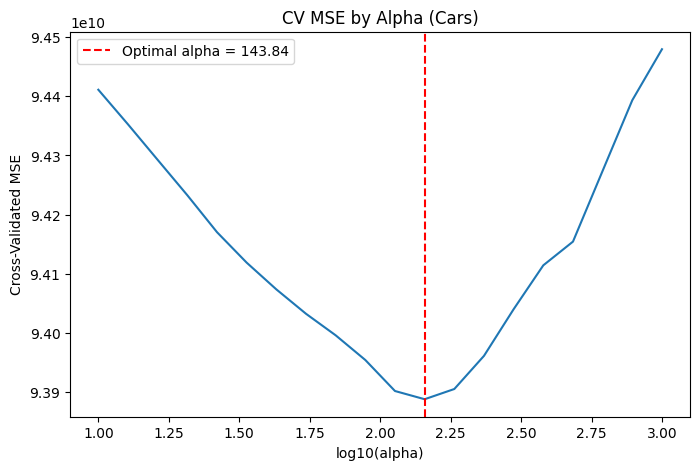

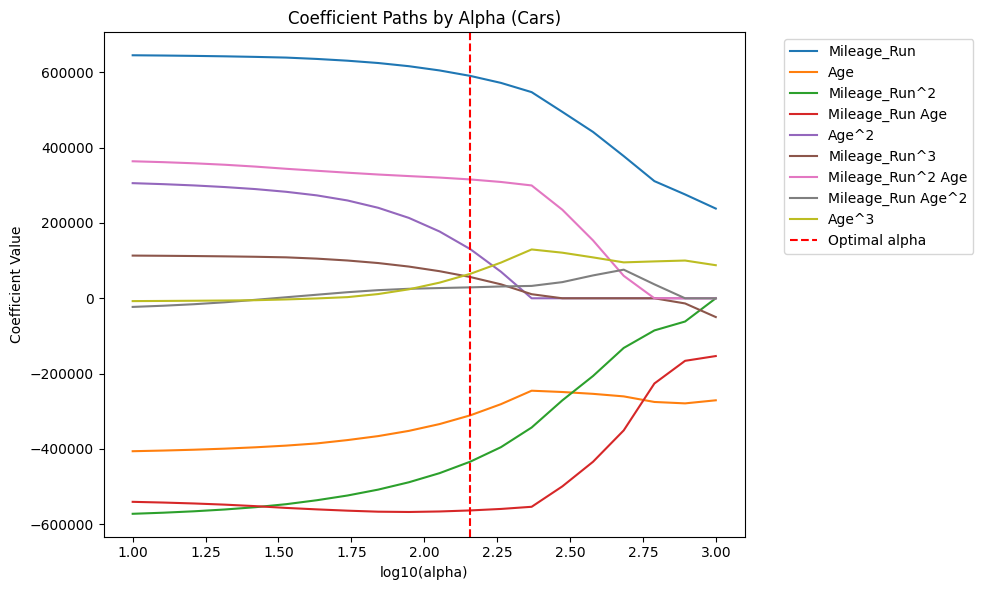


Selected features:
             Feature  LASSO Coefficient
0        Mileage_Run      590420.344996
1                Age     -310779.019923
2      Mileage_Run^2     -433799.302553
3    Mileage_Run Age     -563273.951376
4              Age^2      130525.441246
5      Mileage_Run^3       56444.270689
6  Mileage_Run^2 Age      315528.244311
7  Mileage_Run Age^2       29005.706242
8              Age^3       64855.798834

Proportion zeroed out: 0.00
             Feature  LR Coefficient  LASSO Coefficient  Magnitude Increased  \
0        Mileage_Run    7.861191e+05      590420.344996                False   
1                Age   -2.141229e+05     -310779.019923                 True   
2      Mileage_Run^2   -1.783803e+05     -433799.302553                 True   
3    Mileage_Run Age   -1.453125e+06     -563273.951376                False   
4              Age^2    2.789820e+05      130525.441246                False   
5      Mileage_Run^3   -6.514490e+04       56444.270689                

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

import warnings
warnings.filterwarnings('ignore')
cars = pd.read_csv('./data/cars_hw.csv')
current_year = 2025
cars['Age'] = current_year - cars['Make_Year']

X_raw = cars[['Mileage_Run', 'Age']].values
y = cars['Price'].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


lr = LinearRegression()
lr.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr.coef_})
print(coef_df)

interaction_idx = list(feature_names).index('Mileage_Run Age')
print(f"\nSign of Mileage_Run x Age interaction: {np.sign(lr.coef_[interaction_idx])}")


alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20)
lasso_cv.fit(X_scaled, y)

print(f"\nOptimal alpha: {lasso_cv.alpha_}")


mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure(figsize=(8,5))
plt.plot(np.log10(lasso_cv.alphas_), mse_mean)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Optimal alpha = {lasso_cv.alpha_:.2f}')
plt.xlabel('log10(alpha)')
plt.ylabel('Cross-Validated MSE')
plt.title('CV MSE by Alpha (Cars)')
plt.legend()
plt.show()


coefs = []
for a in alphas:
    from sklearn.linear_model import Lasso
    lasso_temp = Lasso(alpha=a)
    lasso_temp.fit(X_scaled, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)
plt.figure(figsize=(10,6))
for i, name in enumerate(feature_names):
    plt.plot(np.log10(alphas), coefs[:, i], label=name)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Optimal alpha')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths by Alpha (Cars)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


lasso_coefs = pd.DataFrame({
    'Feature': feature_names,
    'LASSO Coefficient': lasso_cv.coef_
})
selected = lasso_coefs[lasso_coefs['LASSO Coefficient'] != 0]
zeroed = lasso_coefs[lasso_coefs['LASSO Coefficient'] == 0]
print(f"\nSelected features:\n{selected}")
print(f"\nProportion zeroed out: {len(zeroed)/len(lasso_coefs):.2f}")


comparison = pd.DataFrame({
    'Feature': feature_names,
    'LR Coefficient': lr.coef_,
    'LASSO Coefficient': lasso_cv.coef_
})
comparison['Magnitude Increased'] = np.abs(lasso_cv.coef_) > np.abs(lr.coef_)
comparison['Sign Changed'] = np.sign(lasso_cv.coef_) != np.sign(lr.coef_)
print(comparison)

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

                                   Feature  Coefficient
0                                      age     1.549928
1                        ejection_fraction    -2.025371
2                         serum_creatinine    -0.739027
3                                    age^2    -3.547991
4                    age ejection_fraction    -0.861860
5                     age serum_creatinine     1.680570
6                      ejection_fraction^2     3.317931
7       ejection_fraction serum_creatinine     2.604767
8                       serum_creatinine^2    -2.703084
9                                    age^3     1.889040
10                 age^2 ejection_fraction     1.022027
11                  age^2 serum_creatinine    -0.672141
12                 age ejection_fraction^2     0.017577
13  age ejection_fraction serum_creatinine    -1.584620
14                  age serum_creatinine^2     1.433246
15                     ejection_fraction^3    -1.253594
16    ejection_fraction^2 serum_creatinine    -1

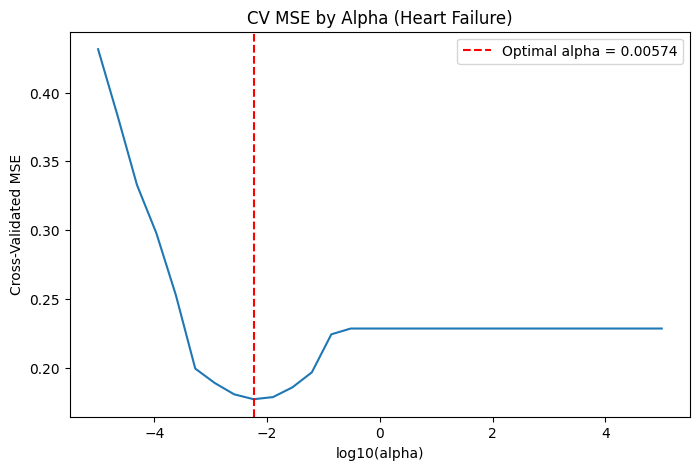

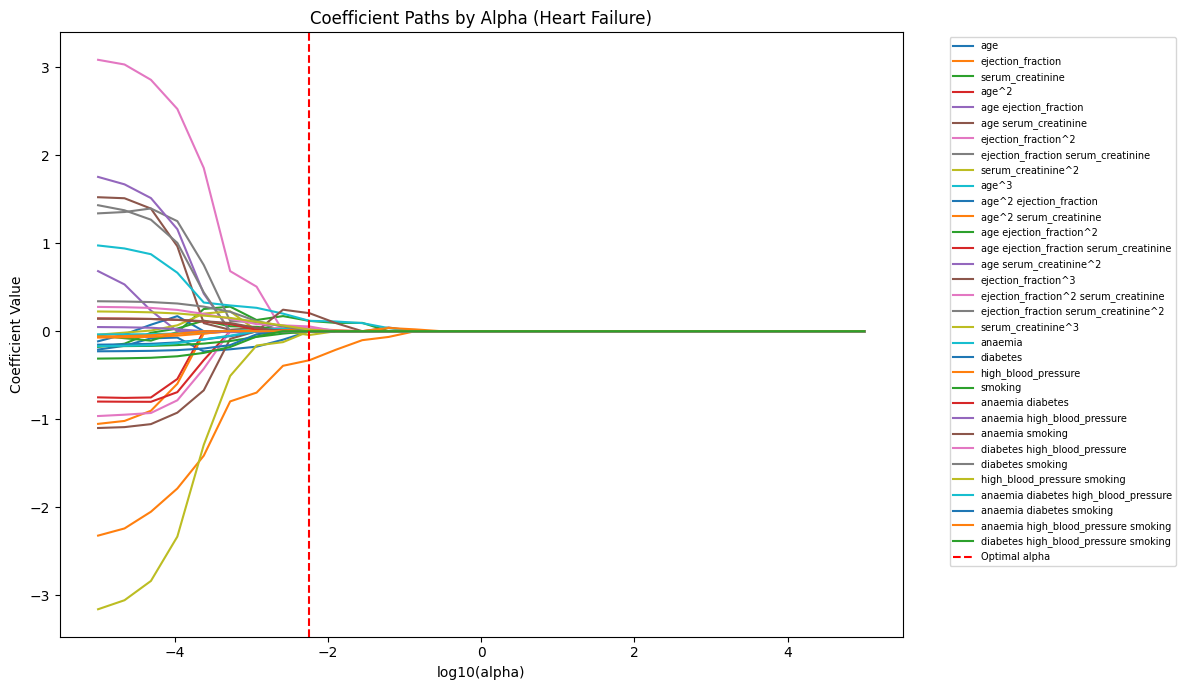


Selected features:
                                 Feature  LR Coefficient  LASSO Coefficient
1                      ejection_fraction       -2.025371          -0.329656
2                       serum_creatinine       -0.739027           0.116875
9                                  age^3        1.889040           0.117992
15                   ejection_fraction^3       -1.253594           0.204822
16  ejection_fraction^2 serum_creatinine       -1.219271           0.032801
18                    serum_creatinine^3       -0.014908          -0.043266
19                               anaemia       -0.043420           0.014178
20                              diabetes       -0.149472           0.000607
21                   high_blood_pressure       -0.073480           0.013608
26          diabetes high_blood_pressure        0.282831           0.053968
27                      diabetes smoking        0.337922           0.003466
28           high_blood_pressure smoking        0.213817           0

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

import warnings
warnings.filterwarnings('ignore')
heart = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

continuous = heart[['age', 'ejection_fraction', 'serum_creatinine']].values
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(continuous)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

dummies = heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']].values
poly_dummy = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_dummy = poly_dummy.fit_transform(dummies)

X = np.concatenate([X_cont_scaled, X_dummy], axis=1)
y = heart['DEATH_EVENT'].values

cont_names = poly_cont.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
dummy_names = poly_dummy.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
feature_names = np.concatenate([cont_names, dummy_names])

lr = LinearRegression()
lr.fit(X, y)

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr.coef_})
print(coef_df)

alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso_cv.fit(X, y)
print(f"\nOptimal alpha: {lasso_cv.alpha_}")

mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure(figsize=(8,5))
plt.plot(np.log10(lasso_cv.alphas_), mse_mean)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Optimal alpha = {lasso_cv.alpha_:.5f}')
plt.xlabel('log10(alpha)')
plt.ylabel('Cross-Validated MSE')
plt.title('CV MSE by Alpha (Heart Failure)')
plt.legend()
plt.show()

coefs = []
for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)
plt.figure(figsize=(12,7))
for i, name in enumerate(feature_names):
    plt.plot(np.log10(alphas), coefs[:, i], label=name)
plt.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label='Optimal alpha')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Paths by Alpha (Heart Failure)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Feature': feature_names,
    'LR Coefficient': lr.coef_,
    'LASSO Coefficient': lasso_cv.coef_
})
selected = comparison[comparison['LASSO Coefficient'] != 0]
zeroed = comparison[comparison['LASSO Coefficient'] == 0]
print(f"\nSelected features:\n{selected}")
print(f"\nProportion zeroed out: {len(zeroed)/len(comparison):.2f}")

comparison['Magnitude Increased'] = np.abs(lasso_cv.coef_) > np.abs(lr.coef_)
comparison['Sign Changed'] = np.sign(lasso_cv.coef_) != np.sign(lr.coef_)
print(comparison)

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?



**1.**

$$L(b_0, b_1) = \frac{1}{n}\sum_{i=1}^n \left(\tilde{y}_i - b_0 - b_1\tilde{x}_i\right)^2 + \alpha b_1^2$$

**2.**

$$\frac{\partial L}{\partial b_0} = \frac{-2}{n}\sum_{i=1}^n(\tilde{y}_i - b_0 - b_1\tilde{x}_i) = 0$$

Since $\sum \tilde{y}_i = 0$ and $\sum \tilde{x}_i = 0$ by construction of the mean-centered variables, this simplifies to $b_0 = 0$.

Taking the derivative with respect to $b_1$ and setting equal to zero:

$$\frac{\partial L}{\partial b_1} = \frac{-2}{n}\sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0$$

Rearranging:

$$\frac{1}{n}\sum \tilde{x}_i\tilde{y}_i = b_1\left(\frac{1}{n}\sum \tilde{x}_i^2 + \alpha\right)$$

Solving for $b_1$:

$$b_1 = \frac{\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum \tilde{x}_i^2 + \alpha}, \qquad b_0 = 0$$

**3.** As $\alpha$ increases, the denominator grows while the numerator remains unchanged, which forces $b_1$ closer to zero. The slope coefficient is increasingly suppressed as the penalty grows stronger.

**4.** The challenge with the L1 penalty $\alpha|b_1|$ is that the absolute value function is not differentiable at $b_1 = 0$, so the standard approach of setting the derivative to zero does not apply at that point. To handle this, we use the concept of a subgradient. For $b_1 \neq 0$, we can differentiate normally and arrive at a solution similar to Ridge, adjusted by $\pm\alpha$. The more interesting case is determining when it is optimal to set $b_1 = 0$. This occurs when the covariance between $\tilde{x}$ and $\tilde{y}$ is not large enough to overcome the penalty, specifically when:

$$\left|\frac{1}{n}\sum \tilde{x}_i\tilde{y}_i\right| \leq \alpha$$

When this condition holds, the penalty dominates the signal and the optimal solution is to set $b_1 = 0$ entirely.